In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [29]:
df = pd.read_csv("../data/analysed_data.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny,AgeGroup
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,3,11,1,69,0,1617,5041,1,60-69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,3,11,0,72,2,27,4491,0,70+
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,3,11,0,61,0,776,4690,0,60-69
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,3,11,0,42,1,53,4517,0,40-49
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,3,11,0,45,1,422,4539,0,40-49


In [30]:
features = ["Age", "Income", "Total_Spending", "NumWebPurchases", "NumStorePurchases", "NumWebVisitsMonth", "Recency"]

In [31]:
X = df[features].copy()

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Finding optimum number of clusters

In [33]:
from sklearn.cluster import KMeans

In [34]:
wcss = []

In [35]:
for i in range(2, 10):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [36]:
wcss

[10368.63176028018,
 9437.969062872271,
 8290.519672562783,
 7694.74304030134,
 7368.931165849092,
 6846.928261962834,
 6331.489023031033,
 6016.200613000941]

Text(0, 0.5, 'WCSS')

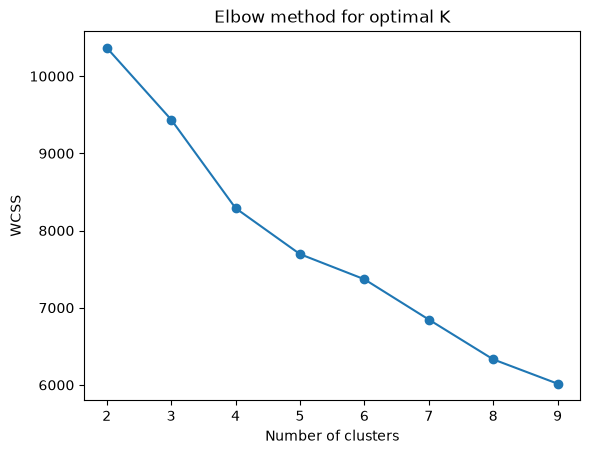

In [37]:
plt.plot(range(2, 10), wcss, marker="o")
plt.title("Elbow method for optimal K")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")

In [38]:
kmeans = KMeans(n_clusters=6)
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [39]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny,AgeGroup,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,11,1,69,0,1617,5041,1,60-69,2
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,3,11,0,72,2,27,4491,0,70+,5
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,3,11,0,61,0,776,4690,0,60-69,4
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,3,11,0,42,1,53,4517,0,40-49,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,11,0,45,1,422,4539,0,40-49,2


In [43]:
cluster_summary = df.groupby("Cluster")[features].mean()
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,48.275969,30647.245736,89.471318,2.080620,2.998450,6.976744,42.534884
1,70.645390,74825.406028,1230.893617,4.471631,8.450355,2.386525,52.868794
2,59.278746,59494.855401,898.846690,7.400697,7.951220,6.205575,73.170732
3,46.865132,79150.547697,1332.901316,4.453947,8.424342,2.486842,49.358553
4,60.319079,58765.366776,766.654605,7.003289,7.552632,6.023026,19.615132
5,65.688995,41012.836124,133.811005,2.248804,3.622010,5.665072,61.466507


In [44]:
df["Cluster"].value_counts()

Cluster
0    645
5    418
4    304
3    304
2    287
1    282
Name: count, dtype: int64

In [45]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df["PCA1"], df["PCA2"] = pca_data[:, 0], pca_data[:,1]

In [46]:
pca_data

array([[ 1.09830647, -0.15639611],
       [-1.32841315,  0.35646684],
       [ 1.87504478, -1.00025966],
       ...,
       [ 1.16575054,  1.0553182 ],
       [ 1.88626188, -1.09870171],
       [-0.84054732, -0.06820811]], shape=(2240, 2))

In [47]:
df["PCA1"]

0       1.098306
1      -1.328413
2       1.875045
3      -1.778951
4       0.022251
          ...   
2235    1.238231
2236    0.495332
2237    1.165751
2238    1.886262
2239   -0.840547
Name: PCA1, Length: 2240, dtype: float64

In [48]:
df["PCA2"]

0      -0.156396
1       0.356467
2      -1.000260
3      -0.770655
4       1.152375
          ...   
2235   -0.535234
2236   -0.012534
2237    1.055318
2238   -1.098702
2239   -0.068208
Name: PCA2, Length: 2240, dtype: float64

Text(0.5, 1.0, 'Customer Segmentation (PCA)')

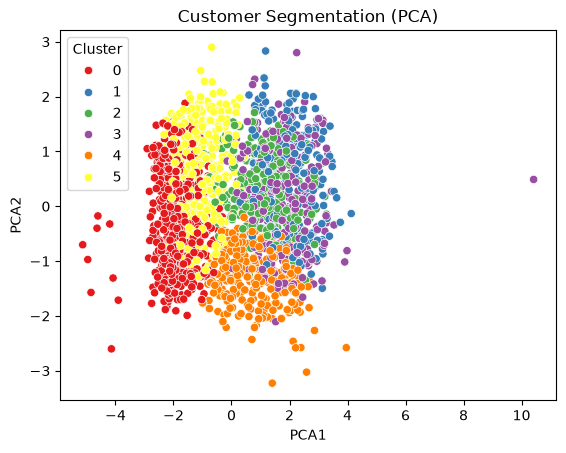

In [50]:
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", data=df, palette="Set1")
plt.title("Customer Segmentation (PCA)")

In [51]:
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,48.275969,30647.245736,89.471318,2.080620,2.998450,6.976744,42.534884
1,70.645390,74825.406028,1230.893617,4.471631,8.450355,2.386525,52.868794
2,59.278746,59494.855401,898.846690,7.400697,7.951220,6.205575,73.170732
3,46.865132,79150.547697,1332.901316,4.453947,8.424342,2.486842,49.358553
4,60.319079,58765.366776,766.654605,7.003289,7.552632,6.023026,19.615132
5,65.688995,41012.836124,133.811005,2.248804,3.622010,5.665072,61.466507


In [52]:
import joblib
joblib.dump(kmeans, "../model/kmeans_model.pkl")
joblib.dump(scaler, "../model/scaler.pkl")

['../model/scaler.pkl']